# Workflow Test: Vacuum Gripper
### Geometries, Gripper, Grasp Sampler

In [1]:
import os
from os.path import join as pjoin
import sys
import numpy as np
import open3d as o3d
import yaml
from copy import deepcopy

# Import our custom modules
# from src.grippers.vacuum_gripper import VacuumGripper, VacuumGripperConfig
from src.grippers.vacuum_gripper_v2 import VacuumGripper, VacuumGripperConfig
# from src.grasping.vacuum_sampler import VacuumGraspSampler, VacuumSamplerConfig
from src.grasping.vacuum_sampler_v2 import VacuumGraspSampler, VacuumSamplerConfig
import src.utils.geometry_utils as gu
from src.generic_geometry import GenericGeometry


### Load Configs and data

In [2]:
# franka_path = pjoin("gripper_parameter", "double_cup.yaml")
franka_path = pjoin("gripper_parameter", "single_circle_cup.yaml")
# franka_path = pjoin("gripper_parameter", "franka_vacuum.yaml")
object_path = pjoin("Test_part", "pringles", "clouds","merged_cloud.ply")

gripper = VacuumGripper(franka_path)
pcd = GenericGeometry(object_path)


✅ Geometry set: mesh (open3d)
Applying rigid transformation...
🔧 Vacuum Gripper 'Double_Schmalz_ECG' initialized.
   - Active Pads: 1
[Open3D WARNING] geometry::TriangleMesh appears to be a geometry::PointCloud (only contains vertices, but no triangles).
[Open3D] Loaded PointCloud: Test_part/pringles/clouds/merged_cloud.ply
✅ Geometry set: point_cloud (open3d)


In [3]:
gripper.visualize()
# pcd.visualize()

## Create Grasp Sampler

In [4]:
# 2. Initialize Sampler Configuration
sampler_config = VacuumSamplerConfig(
    num_samples=400,        # Cast 300 rays
    approach_distance=0.05, # 5cm approach check
    max_curvature=0.15,     # Tolerance for curvature
    min_score=0.1,           # Minimum GSS to accept
    # rotation_strategy='uniform', # 'uniform' or 'fixed'
    rotation_strategy='fixed', # 'uniform' or 'fixed'
    # rotation_step_deg=9,
    # rotation_range_deg=90,
    score_aggregation_method="median",
    debug_score=True

)

# 3. Initialize Sampler
sampler = VacuumGraspSampler(gripper, sampler_config)

[VacuumSampler] Using Contact Strategy: single


### Sample Grasps

In [5]:
pcd.get_dimensions_report()

{'extents_xyz': array([0.0868, 0.0857, 0.2444]),
 'diagonal': 0.2731,
 'likely_unit': 'meters',
 'suggested_voxel_size': 0.00273,
 'details': 'Type: Open3D PointCloud. Size: 0.09 x 0.09 x 0.24. Unit: METERS.'}

In [6]:
# GenericGeometry(geometry=gripper.generate_safety_collision_mesh(
#     np.array([0,0,0]),
#     np.array([0,0,1]),
#     0.2
# )).visualize()

In [7]:
pcd_down = pcd.downsample(voxel_size=0.003)
GenericGeometry(geometry=pcd_down).visualize()

Downsampling with voxel_size=0.003...
✅ Geometry set: point_cloud (open3d)


In [8]:
sampler.config

VacuumSamplerConfig(num_samples=400, approach_distance=0.05, rotation_strategy='fixed', rotation_step_deg=12, rotation_range_deg=180, max_curvature=0.15, max_angle_deg=45.0, min_score=0.1, weight_seal=0.4, weight_verticality=0.3, weight_torque=0.3, score_aggregation_method='median', debug_score=True)

In [9]:
# Run the sampling pipeline
# pcd_down = pcd.downsample(voxel_size=0.003)
grasps = sampler.sample_grasps(pcd_down)

print(f"\nResult: Found {len(grasps)} valid grasps.")

if len(grasps) > 0:
    best_grasp = grasps[0]
    print(f"Top Grasp Score: {best_grasp.score:.4f}")
    print(f"Top Grasp Position: {best_grasp.contact_point}")
else:
    print("No valid grasps found. Check thresholds.")

[VacuumSampler] Phase 1: Generated 400 candidates.
[VacuumSampler] Result: 8 valid grasps.

Result: Found 8 valid grasps.
Top Grasp Score: 0.8213
Top Grasp Position: [-0.00434855  0.01436228  0.24422638]


In [10]:
# for c in sampler.get_best_candidates(8):
for c in [best_grasp]:
# for c in [sampler.candidates[50]]:
    sampler.visualize_grasp(pcd_down, c)

✅ Geometry set: mesh (open3d)
Applying rigid transformation...


In [11]:
cs = filter(lambda c: c.score_details.get('failure_reason','')!='bad_angle', sampler.candidates)

In [12]:
cand_lat = sorted(sampler.candidates, key=lambda c: c.score_details.get('seal_score',0), reverse=False)[0]

In [13]:
len(sampler.candidates)

400

In [14]:
seals = list(filter(lambda c: c.score_details.get("seal_score") == 1, sampler.candidates))

In [15]:
seals
list(map(lambda c: c.score_details.get("seal_score") , sampler.candidates))

[np.float64(0.5714285714285714),
 np.float64(0.5714285714285714),
 np.float64(0.4888888888888889),
 np.float64(0.5581395348837209),
 np.float64(0.40476190476190477),
 np.float64(0.4166666666666667),
 np.float64(0.3333333333333333),
 np.float64(0.5454545454545454),
 np.float64(0.5365853658536586),
 np.float64(0.5116279069767442),
 np.float64(0.4883720930232558),
 np.float64(0.45),
 np.float64(0.43137254901960786),
 np.float64(0.5945945945945946),
 np.float64(0.6),
 np.float64(0.375),
 np.float64(0.5348837209302325),
 np.float64(0.45),
 np.float64(0.6111111111111112),
 np.float64(0.5106382978723404),
 np.float64(0.5319148936170213),
 np.float64(0.46153846153846156),
 np.float64(0.5277777777777778),
 np.float64(0.35555555555555557),
 np.float64(0.4782608695652174),
 np.float64(0.5641025641025641),
 np.float64(0.41025641025641024),
 np.float64(0.5348837209302325),
 np.float64(0.4883720930232558),
 np.float64(0.6578947368421053),
 np.float64(0.55),
 np.float64(0.6511627906976745),
 np.float

(array([ 4.,  3.,  0.,  5.,  5.,  5.,  1.,  5., 14., 27., 54., 60., 58.,
        55., 48., 33., 11.,  6.,  4.,  2.]),
 array([0.02777778, 0.06746032, 0.10714286, 0.1468254 , 0.18650794,
        0.22619048, 0.26587302, 0.30555556, 0.3452381 , 0.38492063,
        0.42460317, 0.46428571, 0.50396825, 0.54365079, 0.58333333,
        0.62301587, 0.66269841, 0.70238095, 0.74206349, 0.78174603,
        0.82142857]),
 <BarContainer object of 20 artists>)

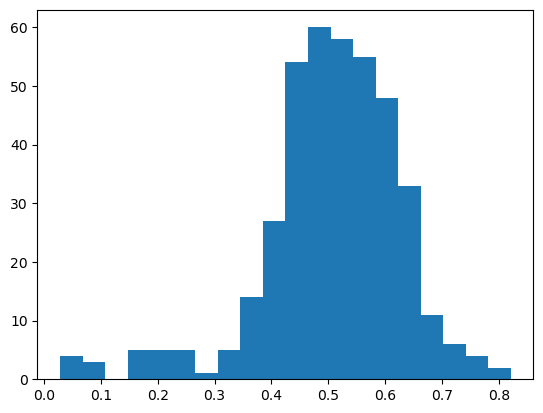

In [16]:
import matplotlib.pyplot as plt
plt.hist(list(map(lambda c: c.score_details.get("seal_score") , sampler.candidates)), bins=20)

In [17]:
sampler.visualize_grasp(pcd_down, sorted(sampler.candidates, key=lambda c: c.score_details.get('seal_score',0), reverse=True)[0])

✅ Geometry set: mesh (open3d)
Applying rigid transformation...


In [18]:
sampler.valid_candidates[0]

GraspCandidate(transform=array([[ 0.99676122,  0.00101377, -0.08041165, -0.00434855],
       [ 0.00101377,  0.99968268,  0.02516971,  0.01436228],
       [ 0.08041165, -0.02516971,  0.9964439 ,  0.24422638],
       [ 0.        ,  0.        ,  0.        ,  1.        ]]), score=np.float64(0.8212774624188616), contact_point=array([-0.00434855,  0.01436228,  0.24422638]), approach_vector=array([ 0.08041165, -0.02516971, -0.9964439 ]), score_details={'seal_score': np.float64(0.6923076923076923), 'verticality': np.float64(0.8925910013522456), 'torque': np.float64(0.9219236169670364), 'raw_angle_deg': np.float64(4.833404939148949), 'pad_scores': {'left_cup': [1.0, 0.8974358974358975, 0.9487179487179487, 0.717948717948718, 0.8974358974358975, 1.0, 0.717948717948718, 0.6923076923076923]}, 'failure_reason': []})

In [19]:
sampler.visualize_candidates_heatmap(pcd_down,attribute='flatness', valid_only=True, relative_scale=False)

Num points: 8, Score Range: [0.000, 0.000]
final_scores Range: [0.000, 0.000]
Here
2
False
True
[Open3D WARNING] [AddGeometry] Invalid pointer. Possibly a null pointer or None was passed in.
[Open3D WARNING] [DrawGeometries] Failed adding geometry.
[Open3D WARNING] [DrawGeometries] Possibly due to bad geometry or wrong geometry type.


In [20]:
sampler.visualize_candidates_heatmap(pcd_down,attribute='verticality', valid_only=True)

Num points: 8, Score Range: [0.542, 0.944]
final_scores Range: [0.542, 0.944]
Here
2
False
[Open3D WARNING] [AddGeometry] Invalid pointer. Possibly a null pointer or None was passed in.
[Open3D WARNING] [DrawGeometries] Failed adding geometry.
[Open3D WARNING] [DrawGeometries] Possibly due to bad geometry or wrong geometry type.


In [21]:
sampler.visualize_candidates_heatmap(pcd_down,attribute='torque', valid_only=True)

Num points: 8, Score Range: [0.240, 0.922]
final_scores Range: [0.240, 0.922]
Here
[Open3D WARNING] [AddGeometry] Invalid pointer. Possibly a null pointer or None was passed in.
[Open3D WARNING] [DrawGeometries] Failed adding geometry.
[Open3D WARNING] [DrawGeometries] Possibly due to bad geometry or wrong geometry type.


In [22]:
sampler.visualize_candidates_heatmap(pcd_down,attribute='seal_score', valid_only=True)

Num points: 8, Score Range: [0.057, 0.692]
final_scores Range: [0.057, 0.692]
Here
[Open3D WARNING] [AddGeometry] Invalid pointer. Possibly a null pointer or None was passed in.
[Open3D WARNING] [DrawGeometries] Failed adding geometry.
[Open3D WARNING] [DrawGeometries] Possibly due to bad geometry or wrong geometry type.


In [33]:
sampler.candidates[0]

GraspCandidate(transform=array([[ 0.95818531,  0.19496553, -0.20945012, -0.00742819],
       [ 0.19496553,  0.09095203,  0.97658393,  0.04974444],
       [ 0.20945012, -0.97658393,  0.04913734,  0.12795424],
       [ 0.        ,  0.        ,  0.        ,  1.        ]]), score=0.0, contact_point=array([-0.00742819,  0.04974444,  0.12795424]), approach_vector=array([-0.20945012,  0.97658393,  0.04913734]), score_details={'flatness': 0.0, 'verticality': 0.0, 'torque': 0.0, 'raw_angle_deg': 0.0, 'pad_scores': {}, 'failure_reason': 'bad_angle'})

In [14]:
sorted(sampler.candidates, key=lambda c: c.score_details.get('verticality',0), reverse=True)[0]

GraspCandidate(transform=array([[ 0.35293315,  0.93531597,  0.0249443 ,  0.02266724],
       [ 0.93531597, -0.35197155, -0.03605625,  0.00525901],
       [-0.0249443 ,  0.03605625, -0.9990384 ,  0.24682066],
       [ 0.        ,  0.        ,  0.        ,  1.        ]]), score=0.0, contact_point=array([0.02266724, 0.00525901, 0.24682066]), approach_vector=array([-0.0249443 ,  0.03605625,  0.9990384 ]), score_details={'flatness': np.float64(0.0), 'verticality': np.float64(0.9441585468554655), 'torque': np.float64(0.3253895587166594), 'raw_angle_deg': np.float64(2.5128653915040537), 'pad_scores': {'left_cup': 0.0}, 'failure_reason': ['bad_seal']})

In [16]:
sorted(sampler.candidates, key=lambda c: c.score_details.get('torque',0), reverse=True)[0]

GraspCandidate(transform=array([[-0.81829508,  0.56914597,  0.08041165, -0.00434855],
       [ 0.56914597,  0.82185117, -0.02516971,  0.01436228],
       [-0.08041165,  0.02516971, -0.9964439 ,  0.24422638],
       [ 0.        ,  0.        ,  0.        ,  1.        ]]), score=0.0, contact_point=array([-0.00434855,  0.01436228,  0.24422638]), approach_vector=array([-0.08041165,  0.02516971,  0.9964439 ]), score_details={'flatness': np.float64(0.0), 'verticality': np.float64(0.8925910013522456), 'torque': np.float64(0.9219236169670364), 'raw_angle_deg': np.float64(4.833404939148949), 'pad_scores': {'left_cup': 0.0}, 'failure_reason': ['bad_seal']})